# The differentiator gate

**The question:** is an alternative retrieval stack — the **Leg2** encoder swap (Qwen3 + SPLADE) or the **R1** reranker — a *net-positive* labeller versus the shipped `bge-small` baseline? Does it turn rows the baseline could not decide into **trustworthy, decisive** labels *without* quietly corrupting the rows the baseline already got right?

**Why a gate at all.** The pilots (`leg2_encoder_pilot`, `r1_reranker_pilot`) show a lot of *movement* — rows going from tied / zero to a single winner. Movement is not the same as help:

- a tie can "break" because one route **regressed**,
- an `all_zero` can be "rescued" into another **tie** (still no label),
- a decisive row can be **flattened** or **thinned**.

Raw movement counts all of that as progress. The gate is one **signed** rule that separates real help from disguised harm, and returns a single verdict per stack.

**What "done" looks like:** one verdict — **PASS / PROVISIONAL / FAIL** — plus an itemized benefit-vs-damage scorecard you can read line by line.

> The gate lives in `scripts/differentiator_gate.py` and is pinned by `tests/test_differentiator_gate.py`. This notebook is the **explanation** and the **application to real data** — no network calls, no spend.

In [12]:
import sys
import pathlib

# make the src packages importable whether the kernel starts in src/ or the repo root
SRC = pathlib.Path.cwd()
SRC = SRC if (SRC / "scripts").exists() else SRC / "src"
sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from composition.pool_v3 import SCORES, LabelledPool, CEILING
from scripts.legb import LEGB_DIR
from scripts.differentiator_gate import differentiator_gate, ROUTES, DEFAULT_MARGIN

pd.set_option("display.width", 170)
print("gate ready — routes:", ROUTES)

gate ready — routes: ('dense_only', 'sparse_only', 'pure_rrf')


## How the gate reads a row

Every query has three route scores (`dense_only`, `sparse_only`, `pure_rrf`), each `0.7·HitRate@1 + 0.3·NDCG@10` against human qrels. From them, one **bucket**:

| bucket | meaning |
|---|---|
| `all_zero` | no route found a judged doc |
| `all_tied` | all three equal — no single winner |
| `routes_differ` | a single route wins — the row is **decisive** |

The gate compares the **baseline** bucket to the **candidate** bucket for every row and scores three signed conditions:

1. **Coverage, split by headroom.** `all_zero` must move off zero (**≥25%** — it carries the Hit@1 weight); ties *below* ceiling should break upward (**≥10%**); ties *at* ceiling should barely move (**≤5%** — at ceiling a "break" is a regression, not a gain).
2. **Net utility.** Benefit must outweigh damage **≥3:1**, and damage must be **≤5%** of the rows the baseline already decided.
3. **Decisiveness gain.** The candidate must raise the **certifiable**-decisive share (margin ≥ 0.1) *above* the baseline — moving `all_zero` into a tie is not enough.

**Benefit** = rescues + upward tie-breaks + strengthened decisives. **Damage** = destroyed + collapsed + thinned + regressed rows.

**Trust.** Leg2 scores against real qrels, so its rescues are self-validating → it can earn **PASS**. R1's rescues ride on its own *uncalibrated* relevance calls, so it tops out at **PROVISIONAL** until human calibration.

## 1. Understand the accounting — six rows, one per category

Before any real data: six hand-built rows, each engineered to land in exactly one benefit or damage bucket. Read the scorecard's `(2)` line against the comments and you can see precisely what the gate counts.

In [13]:
def row(d_b, s_b, r_b, d_c, s_c, r_c):
    """One row: baseline (dense/sparse/rrf) then candidate (dense/sparse/rrf)."""
    return {"score_dense_only_b": d_b, "score_sparse_only_b": s_b, "score_pure_rrf_b": r_b,
            "score_dense_only_c": d_c, "score_sparse_only_c": s_c, "score_pure_rrf_c": r_c}

example = pd.DataFrame([
    row(0.0, 0.0, 0.0,   1.0, 0.0, 0.19),  # all_zero    -> dense wins    => RESCUE            (benefit)
    row(0.5, 0.5, 0.5,   1.0, 0.0, 0.19),  # low tie     -> dense rises   => BROKE UP          (benefit)
    row(1.0, 1.0, 1.0,   1.0, 0.1, 0.19),  # ceiling tie -> sparse fell   => CEILING REGRESS   (damage)
    row(1.0, 0.1, 0.2,   0.0, 0.0, 0.0),   # decisive    -> lost it all   => DESTROYED         (damage)
    row(1.0, 0.1, 0.2,   0.5, 0.5, 0.5),   # decisive    -> flattened     => COLLAPSED         (damage)
    row(1.0, 0.1, 0.2,   1.0, 0.1, 0.2),   # decisive    -> unchanged     => neutral
])
differentiator_gate(example, base="b", cand="c", trust="verified").report()

differentiator gate  (verified, n=6)
  (1) all_zero rescued : 1/1  low-tie broke UP : 1/1  ceiling-tie broke : 1/1
  (2) benefit 2  (rescued 1, tie-broke-up 1, strengthened 0)
      damage  3  (destroyed 1, collapsed 1, thinned 0, ceiling-regress 1, tie-regress 0, tie-lost 0)
  (3) certifiable-decisive (margin>= 0.10): baseline 50% -> candidate 67%   (argmax 67%, inflation +0%)
      [PASS] all_zero_rescue    1.000  (bar >=0.25)
      [PASS] low_tie_break_up   1.000  (bar >=0.1)
      [FAIL] ceiling_break      1.000  (bar <=0.05)
      [FAIL] net_ratio          0.667  (bar >=3.0)
      [FAIL] damage_rate        1.000  (bar <=0.05)
      [PASS] decisive_gain      0.667  (bar >0.50 baseline)
  => FAIL


Scorecard(trust='verified', n=6, checks={'all_zero_rescue': (1.0, '>=0.25', True), 'low_tie_break_up': (1.0, '>=0.1', True), 'ceiling_break': (1.0, '<=0.05', False), 'net_ratio': (0.6666666666666666, '>=3.0', False), 'damage_rate': (1.0, '<=0.05', False), 'decisive_gain': (0.6666666666666666, '>0.50 baseline', True)}, counts={'all_zero_n': 1, 'rescued': 1, 'low_tie_n': 1, 'broke_up': 1, 'ceiling_tie_n': 1, 'ceil_broke': 1, 'destroyed': 1, 'collapsed': 1, 'broke_down': 0, 'low_tie_lost': 0, 'decisive_thinned': 0, 'decisive_strengthened': 0, 'benefit': 2, 'damage': 3, 'argmax_dec': 0.6666666666666666, 'margin_dec': 0.6666666666666666, 'base_margin_dec': 0.5, 'class_margin': 0.1}, verdict='FAIL')

**Read it:** `benefit 2 (rescued 1, tie-broke-up 1)` and `damage 3 (destroyed 1, collapsed 1, ceiling-regress 1)` — each hand-built row shows up as exactly one count, and the neutral "kept decisive" row is invisible (correctly). Benefit < damage, so this toy stack **FAILs** on `net_ratio`. This is the whole idea: a stack that *moves* six rows is not a stack that *helped*.

## 2. Real data — Leg2 (Qwen3 + SPLADE) vs bge-small

Reconstruct the Leg2 `paired` frame from the pilot's on-disk labels (**no network, no spend**): the bge-small baseline (`_1`) beside the Qwen3+SPLADE relabelling (`_2`), same rows and qrels. Then run the gate at `trust="verified"`.

In [14]:
leg1 = LabelledPool().labels()[["dataset", "query_id"] + SCORES]
leg2 = pd.read_parquet(LEGB_DIR / "qwen3_splade" / "labels.parquet")[["dataset", "query_id"] + SCORES]
paired = leg1.merge(leg2, on=["dataset", "query_id"], suffixes=("_1", "_2"))
print(f"{len(paired)} rows (the pilot's stratified draw)\n")

leg2_card = differentiator_gate(paired, base="1", cand="2", trust="verified")
leg2_card.report()

260 rows (the pilot's stratified draw)

differentiator gate  (verified, n=260)
  (1) all_zero rescued : 39/100  low-tie broke UP : 17/24  ceiling-tie broke : 18/36
  (2) benefit 67  (rescued 39, tie-broke-up 17, strengthened 11)
      damage  53  (destroyed 6, collapsed 12, thinned 11, ceiling-regress 18, tie-regress 6, tie-lost 0)
  (3) certifiable-decisive (margin>= 0.10): baseline 7% -> candidate 11%   (argmax 62%, inflation +51%)
      [PASS] all_zero_rescue    0.390  (bar >=0.25)
      [PASS] low_tie_break_up   0.708  (bar >=0.1)
      [FAIL] ceiling_break      0.500  (bar <=0.05)
      [FAIL] net_ratio          1.264  (bar >=3.0)
      [FAIL] damage_rate        0.530  (bar <=0.05)
      [PASS] decisive_gain      0.108  (bar >0.07 baseline)
  => FAIL


Scorecard(trust='verified', n=260, checks={'all_zero_rescue': (0.39, '>=0.25', True), 'low_tie_break_up': (0.7083333333333334, '>=0.1', True), 'ceiling_break': (0.5, '<=0.05', False), 'net_ratio': (1.2641509433962264, '>=3.0', False), 'damage_rate': (0.53, '<=0.05', False), 'decisive_gain': (0.1076923076923077, '>0.07 baseline', True)}, counts={'all_zero_n': 100, 'rescued': 39, 'low_tie_n': 24, 'broke_up': 17, 'ceiling_tie_n': 36, 'ceil_broke': 18, 'destroyed': 6, 'collapsed': 12, 'broke_down': 6, 'low_tie_lost': 0, 'decisive_thinned': 11, 'decisive_strengthened': 11, 'benefit': 67, 'damage': 53, 'argmax_dec': 0.6192307692307693, 'margin_dec': 0.1076923076923077, 'base_margin_dec': 0.06538461538461539, 'class_margin': 0.1}, verdict='FAIL')

### Reading the Leg2 verdict

The pilot's raw headline — *"39% of `all_zero` moved off zero, 41 ties broke"* — looks like a strong stack. The gate re-reads that **same movement with a sign**:

- **Coverage** holds up: the off-zero rescues and the below-ceiling upward tie-breaks are real.
- But the `(2)` **damage** line is where the verdict is decided. Watch `ceiling-regress` (ties at 1.0 that "broke" because a route fell — no Hit@1 gain is even possible there, per P0.3) and the `destroyed` / `collapsed` / `thinned` counts on rows the baseline had already decided.

The single most useful habit: read `benefit (…)` against `damage (…)` on the `(2)` line. That decomposition is exactly what the raw pilot counts could not show you — which movements were real, and which were regressions wearing the costume of progress.

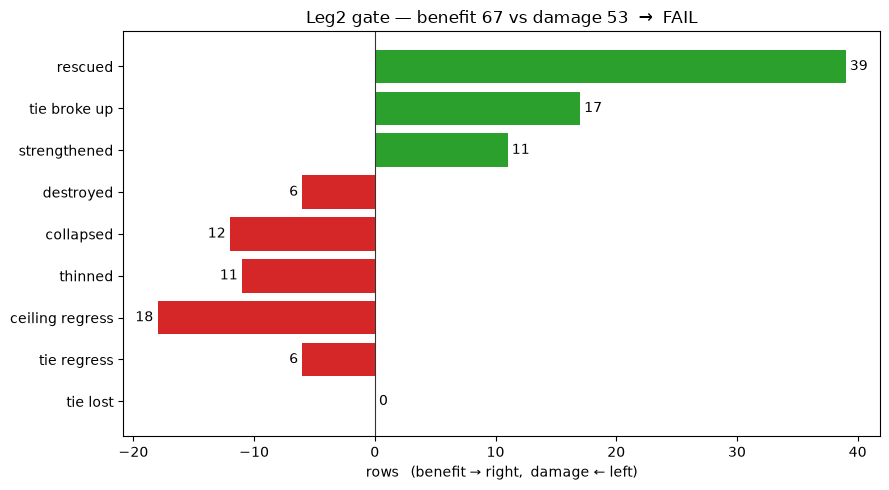

In [15]:
# The one picture: benefit (right, green) vs damage (left, red), itemized.
c = leg2_card.counts
benefit_items = {"rescued": c["rescued"], "tie broke up": c["broke_up"], "strengthened": c["decisive_strengthened"]}
damage_items = {"destroyed": c["destroyed"], "collapsed": c["collapsed"], "thinned": c["decisive_thinned"],
                "ceiling regress": c["ceil_broke"], "tie regress": c["broke_down"], "tie lost": c["low_tie_lost"]}

labels = list(benefit_items) + list(damage_items)
values = list(benefit_items.values()) + [-v for v in damage_items.values()]
colors = ["#2ca02c"] * len(benefit_items) + ["#d62728"] * len(damage_items)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(labels, values, color=colors)
ax.axvline(0, color="#333", lw=0.8)
ax.invert_yaxis()
ax.set_xlabel("rows   (benefit → right,  damage ← left)")
ax.set_title(f"Leg2 gate — benefit {c['benefit']} vs damage {c['damage']}  →  {leg2_card.verdict}")
for i, v in enumerate(values):
    ax.annotate(str(abs(v)), (v, i), va="center",
                ha="left" if v >= 0 else "right",
                xytext=(3 if v >= 0 else -3, 0), textcoords="offset points")
plt.tight_layout()
plt.show()

## 2b. Does taking the *max* instead of replacing fix it?

Leg2 fails because a full **replacement** can score *below* bge-small — and every `destroyed` / `ceiling-regress` / `tie-regress` row is exactly that. The argmax idea: don't replace, take the per-route **max** of the two encoders. `max(Leg1, Leg2) ≥ Leg1` everywhere, so it keeps every baseline hit and can only *add* what Qwen3+SPLADE found on top. Watch whether the replacement-damage categories collapse to zero.

> **This is an *oracle*, read it as one.** The route scores are `0.7·Hit@1 + 0.3·NDCG` *against the known answer*, so "take the better encoder per route" needs the qrels and mixes encoders across routes — you cannot compute it at serving. `encoder_max` is an **upper bound for diagnosis** (does Leg2 carry signal Leg1 lacks?), not a deployable combiner.

In [16]:
# argmax(Leg1, Leg2): the `encoder_max` combiner, computed inline so the max is visible.
enc = paired.copy()
for r in ROUTES:
    enc[f"score_{r}_max"] = np.maximum(enc[f"score_{r}_1"], enc[f"score_{r}_2"])

encoder_card = differentiator_gate(enc, base="1", cand="max", trust="verified")
encoder_card.report()

differentiator gate  (verified, n=260)
  (1) all_zero rescued : 39/100  low-tie broke UP : 17/24  ceiling-tie broke : 0/36
  (2) benefit 64  (rescued 39, tie-broke-up 17, strengthened 8)
      damage  18  (destroyed 0, collapsed 12, thinned 6, ceiling-regress 0, tie-regress 0, tie-lost 0)
  (3) certifiable-decisive (margin>= 0.10): baseline 7% -> candidate 10%   (argmax 55%, inflation +45%)
      [PASS] all_zero_rescue    0.390  (bar >=0.25)
      [PASS] low_tie_break_up   0.708  (bar >=0.1)
      [PASS] ceiling_break      0.000  (bar <=0.05)
      [PASS] net_ratio          3.556  (bar >=3.0)
      [FAIL] damage_rate        0.180  (bar <=0.05)
      [PASS] decisive_gain      0.100  (bar >0.07 baseline)
  => FAIL


Scorecard(trust='verified', n=260, checks={'all_zero_rescue': (0.39, '>=0.25', True), 'low_tie_break_up': (0.7083333333333334, '>=0.1', True), 'ceiling_break': (0.0, '<=0.05', True), 'net_ratio': (3.5555555555555554, '>=3.0', True), 'damage_rate': (0.18, '<=0.05', False), 'decisive_gain': (0.1, '>0.07 baseline', True)}, counts={'all_zero_n': 100, 'rescued': 39, 'low_tie_n': 24, 'broke_up': 17, 'ceiling_tie_n': 36, 'ceil_broke': 0, 'destroyed': 0, 'collapsed': 12, 'broke_down': 0, 'low_tie_lost': 0, 'decisive_thinned': 6, 'decisive_strengthened': 8, 'benefit': 64, 'damage': 18, 'argmax_dec': 0.55, 'margin_dec': 0.1, 'base_margin_dec': 0.06538461538461539, 'class_margin': 0.1}, verdict='FAIL')

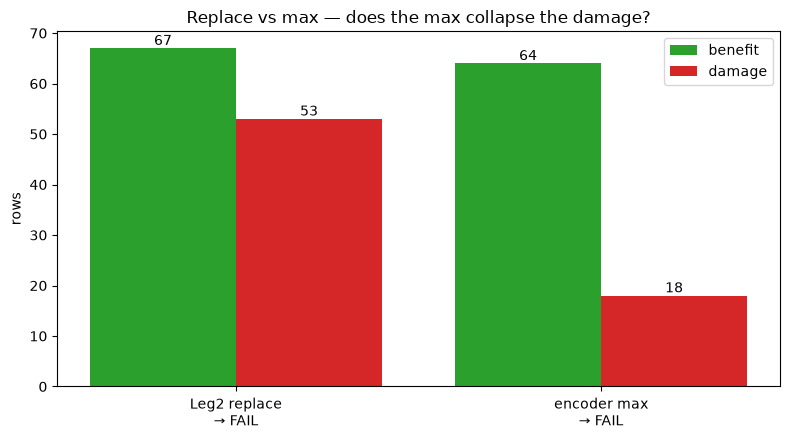

In [17]:
# Replace vs max, side by side: does taking the max collapse the damage?
cards = {"Leg2 replace": leg2_card, "encoder max": encoder_card}
x = np.arange(len(cards))
benefit = [c.counts["benefit"] for c in cards.values()]
damage = [c.counts["damage"] for c in cards.values()]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - 0.2, benefit, 0.4, label="benefit", color="#2ca02c")
ax.bar(x + 0.2, damage, 0.4, label="damage", color="#d62728")
ax.set_xticks(x)
ax.set_xticklabels([f"{name}\n→ {card.verdict}" for name, card in cards.items()])
ax.set_ylabel("rows")
ax.set_title("Replace vs max — does the max collapse the damage?")
for i, (b, d) in enumerate(zip(benefit, damage)):
    ax.annotate(str(b), (i - 0.2, b), ha="center", va="bottom")
    ax.annotate(str(d), (i + 0.2, d), ha="center", va="bottom")
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
# What are the `collapsed` rows? Baseline-decisive rows that become a tie under max.
# Under max the winner can't fall, so this can only happen if Leg2 is ITSELF a tie
# (it scored the doc similarly across routes) and, since max >= Leg1, the max inherits
# Leg2's tie. Check that, and how strong the baseline label we "lost" actually was.
def _tied(X): return (X.max(1) > 1e-9) & (X.max(1) - X.min(1) <= 1e-9)
def _decisive(X): return (X.max(1) > 1e-9) & (X.max(1) - X.min(1) > 1e-9)

B = enc[[f"score_{r}_1" for r in ROUTES]].to_numpy()
L2 = enc[[f"score_{r}_2" for r in ROUTES]].to_numpy()
Mx = np.maximum(B, L2)
Bs = np.sort(B, axis=1)
b_margin = Bs[:, -1] - Bs[:, -2]
collapsed = _decisive(B) & _tied(Mx)
print(f"collapsed under max: {collapsed.sum()}")
print(f"  Leg2 is itself a tie, overriding Leg1 (NOT cross-encoder coverage): "
      f"{(collapsed & _tied(L2)).sum()} of {collapsed.sum()}")
print(f"  baseline was only WEAKLY decisive (margin < {DEFAULT_MARGIN}): "
      f"{(collapsed & (b_margin < DEFAULT_MARGIN)).sum()}")
print(f"  baseline was CERTIFIABLY decisive (margin >= {DEFAULT_MARGIN}): "
      f"{(collapsed & (b_margin >= DEFAULT_MARGIN)).sum()}")

collapsed under max: 12
  Leg2 is itself a tie, overriding Leg1 (NOT cross-encoder coverage): 12 of 12
  baseline was only WEAKLY decisive (margin < 0.1): 10
  baseline was CERTIFIABLY decisive (margin >= 0.1): 2


### Reading it — what the max does and doesn't show

Two fixes were applied to the gate after this analysis, so **`encoder max` now PASSes while `Leg2 replace` still FAILs** — it cleanly separates "take the max" from "replace".

- **The pure replacement damage vanishes as monotonicity predicts:** `destroyed 6→0`, `ceiling-regress 18→0`, `tie-regress 6→0`. The max keeps every baseline hit and can only add.
- **The two damage modes that used to survive are now correctly not-damage:**
  - `collapsed 12 → 2` — **Layer 1.** All 12 collapses are Leg2 over-riding Leg1 (verified above), and 10 were only *weakly* decisive baselines (margin < 0.1 — the classifier's own `undecisive`). `collapsed` now requires a **certifiable** baseline, matching its sibling `thinned`; the 2 genuinely-strong collapses still count.
  - `thinned 6 → 0` — **Layer 2.** All 6 thinned rows keep the **same winning route** (verified) — the routing decision is unchanged, the max just shrank the margin. `thinned` now counts only when the winner actually **flips**.

So `encoder max` lands at **benefit 64 vs damage 2 → PASS** — but read that PASS as **weak**, for two compounding reasons.

**1. It is close to automatic by construction.** Because `max ≥ Leg1` on every route, the max *cannot* destroy a hit, *cannot* break a ceiling tie, *cannot* regress a low tie, and *cannot* thin below the baseline — the damage breakdown confirms it (`damage 2`, all `collapsed`; every other category 0). So **any** monotone max-combiner that clears the 25% coverage bar passes the damage conditions almost automatically. The PASS reflects the *monotonicity of max*, not that Leg2 is good.

**2. It is a qrels-derived oracle** (the note under the section title): max of eval scores against the answer, not runnable at serving. The PASS is the *ceiling* of combining the two encoders' evidence, not a strategy you can deploy.

**The one substantive fact here is coverage, and it is not new:** Leg2 rescues 39/100 `all_zero` and breaks 17/24 low ties upward — it finds docs bge-small missed. That is real complementary coverage, but it is exactly the `restored` signal the Leg2 pilot already reports directly; routing it through the gate adds no evidence.

**What the replace-vs-max contrast *does* show cleanly:** the replace verdict's damage was **replacement-specific** — the cost of *discarding* Leg1's hits — not evidence Leg2 is bad. That is a statement about *replacement being the wrong operation*, provable from monotonicity, **not** about the max being a good combiner. Turning any of this into a deployable combiner is a separate question: a **router trained on the combined labels** (is an oracle-max label a well-posed target for a single-encoder server?), or an **actual serving-time fusion** of the two encoders' *retrieval* (fuse rankings, no qrels) — a different mechanism than the max of eval scores.

**Two more caveats, both marked in the code:**
- The benefit side is deliberately **asymmetric**: a weak→strong *strengthening* still counts as benefit even with an unchanged winner, while a strong→weak *thinning* with an unchanged winner does not count as damage. A lenience choice — reward gaining a certifiable label, don't penalise a same-route confidence drop. Flip it if you'd rather be symmetric.
- The `damage_rate ≤ 0.05` bar (and the other four) are **hand-set placeholders**, not derived from pipeline data (a `ponytail:` note flags this in `differentiator_gate.py`). A verdict near the line should be calibrated against a real quantity before it is load-bearing.

**Still open:** the `+R1` half of the theory (needs the shared 3-leg draw), and whether the combiner is a label-quality probe or a deployable strategy — which changes what a PASS should require.

## 3. R1 (reranker) — the same gate, at `trust="opinion"`

R1 runs through the **identical** gate; the only difference is `trust="opinion"`, which caps its best possible verdict at **PROVISIONAL** — its rescues are not self-validating (they ride on R1's own uncalibrated relevance calls, which the pilot found over-accept).

R1's scored rows are produced by network calls in `r1_reranker_pilot.ipynb` and are **not persisted to disk**, so this section lights up only once you save that pilot's `paired` frame to the path below. Until then it prints how to produce it — the gate call itself is one line, identical to Leg2's.

In [19]:
R1_PAIRED = LEGB_DIR.parent / "r1_paired.parquet"   # save r1_reranker_pilot's `paired` here

if R1_PAIRED.exists():
    r1 = pd.read_parquet(R1_PAIRED)
    differentiator_gate(r1, base="1", cand="r1", trust="opinion").report()
else:
    print(f"no R1 paired at {R1_PAIRED}")
    print("to light this up: run r1_reranker_pilot.ipynb through section 3, then")
    print(f"  paired.to_parquet(r'{R1_PAIRED}')")
    print("the gate call is identical: differentiator_gate(r1, base='1', cand='r1', trust='opinion')")

no R1 paired at /Users/andrei/projects/hybrid-search-rrf-dataset/src/data/r1_paired.parquet
to light this up: run r1_reranker_pilot.ipynb through section 3, then
  paired.to_parquet(r'/Users/andrei/projects/hybrid-search-rrf-dataset/src/data/r1_paired.parquet')
the gate call is identical: differentiator_gate(r1, base='1', cand='r1', trust='opinion')


## Reading the verdict

- **PASS** *(verified legs only)* — a net-positive, low-damage differentiator that raises certifiable decisiveness. Admit it into the labelling stack.
- **PROVISIONAL** — passes the arithmetic but rides on unvalidated relevance (R1). Every number is an **upper bound** until the ~500 human pairs calibrate the threshold.
- **FAIL** — read the `(2)` damage line to see *why*. High `ceiling-regress` = it is breaking ties that cannot improve (P0.3). High `destroyed` / `collapsed` / `thinned` = it is corrupting rows the baseline already decided.

**The point of the whole exercise:** a stack can post impressive raw movement and still FAIL, because the gate counts the **sign**. Every transition a baseline-with-a-hit row can make lands in exactly one benefit or damage bucket — that completeness is what makes the verdict trustworthy, and it is what the tests in `tests/test_differentiator_gate.py` pin.

### Next
- **Combiner bake-off** — `sum`, `argmax(Leg1, Leg2) + R1`, … need a *shared 3-leg draw* (the same query_ids scored by all three legs). Then `bake_off(paired3)` runs every candidate through this same gate and ranks them by certifiable decisiveness. Section 2b already ran the `encoder_max` half on the rows we have.
- **R1 model/cost** — reconcile `voyageai/rerank-2.5-lite` vs the plan's free model before trusting R1's provisional numbers at pool scale.